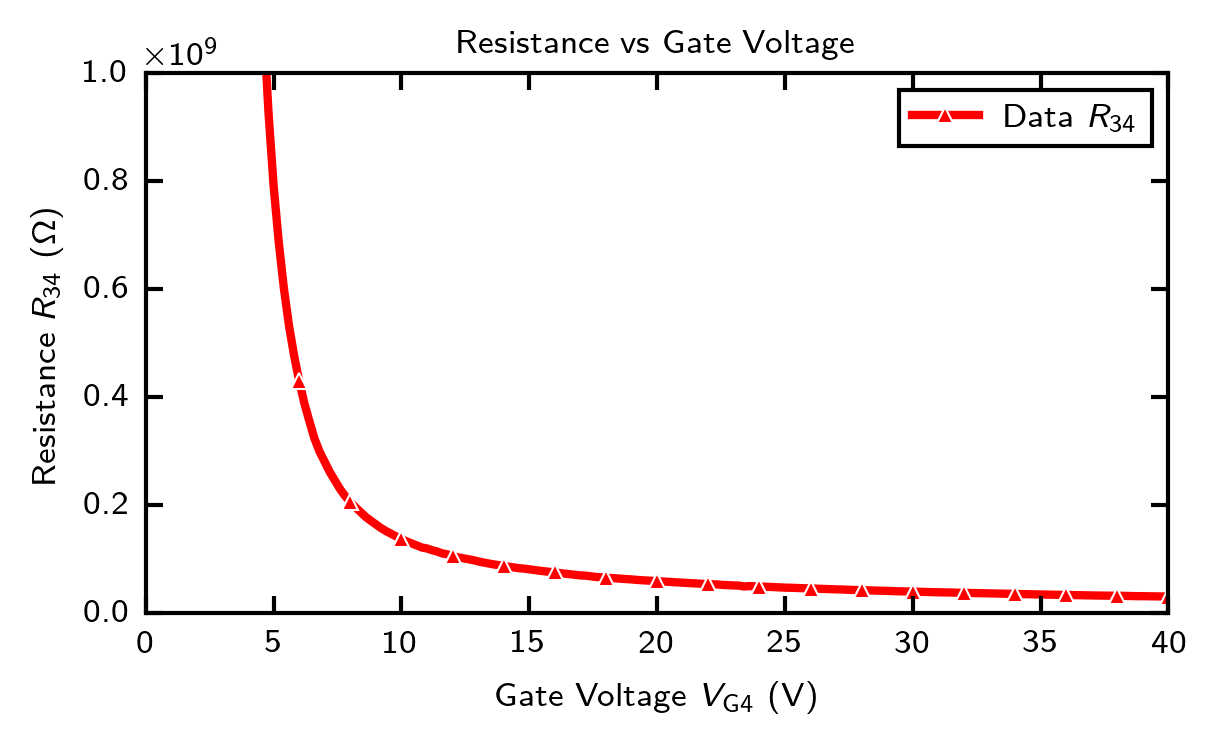

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings for python figures
plt.style.use('classic')

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'''
    \usepackage[T1]{fontenc}
    \usepackage{lmodern}
    \usepackage[utf8]{inputenc}
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage{siunitx}
    \usepackage{sfmath}
    '''
})
plt.rcParams.update({
    # Figure settings
    'figure.dpi': 300,
    'figure.figsize': (10/2.54, 6/2.54),  # 10x6 cm in inches (1 figure per line)
    # 'figure.figsize': (8/2.54, 6/2.54),  # 10x6 cm in inches (2 figures per line)
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    # 'mathtext.fontset': 'cm',
    'figure.constrained_layout.use': True,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
    "xtick.minor.width":0,
    "ytick.minor.width": 0,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,  

    # Legend
    'legend.frameon': False,
    'legend.title_fontsize': 8,
    'legend.fontsize': 8,
    'legend.handlelength': 2,
    'legend.loc': 'best',
    'legend.numpoints': 1,

    # Line style
    'lines.linestyle': '-',
    'lines.linewidth': 1,
    'lines.markersize': 4,
    'lines.markeredgecolor': 'white',
    'lines.markeredgewidth': 0.5,
})


# IDS - VGS data
data1 = np.loadtxt("./Data-IDS-VGS/20262504001.dat")
V_GS = -data1[:, 0]  # VGS values
I_DS = -data1[:, 1]  # IDS values
V_DS = -data1[:, 2]  # VDS values
R_DS = V_DS / I_DS  # Calculate 
x = V_GS 

plt.plot(x, R_DS, lw=2, label=r'Data $R_\text{34}$', color='red', marker='^', linestyle='-', markevery=10)
plt.xlabel(r"Gate Voltage $V_\text{G4}$ (V)")
plt.ylabel(r"Resistance $R_\text{34}$ ($\Omega$)")
plt.xlim(0,40)
plt.ylim(0, 1e9)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()


a = R_\infty = -5.12867e+06 ± 4.61e+05
b = 1.31596e+09 ± 9.19e+06
R^2 = 0.992782


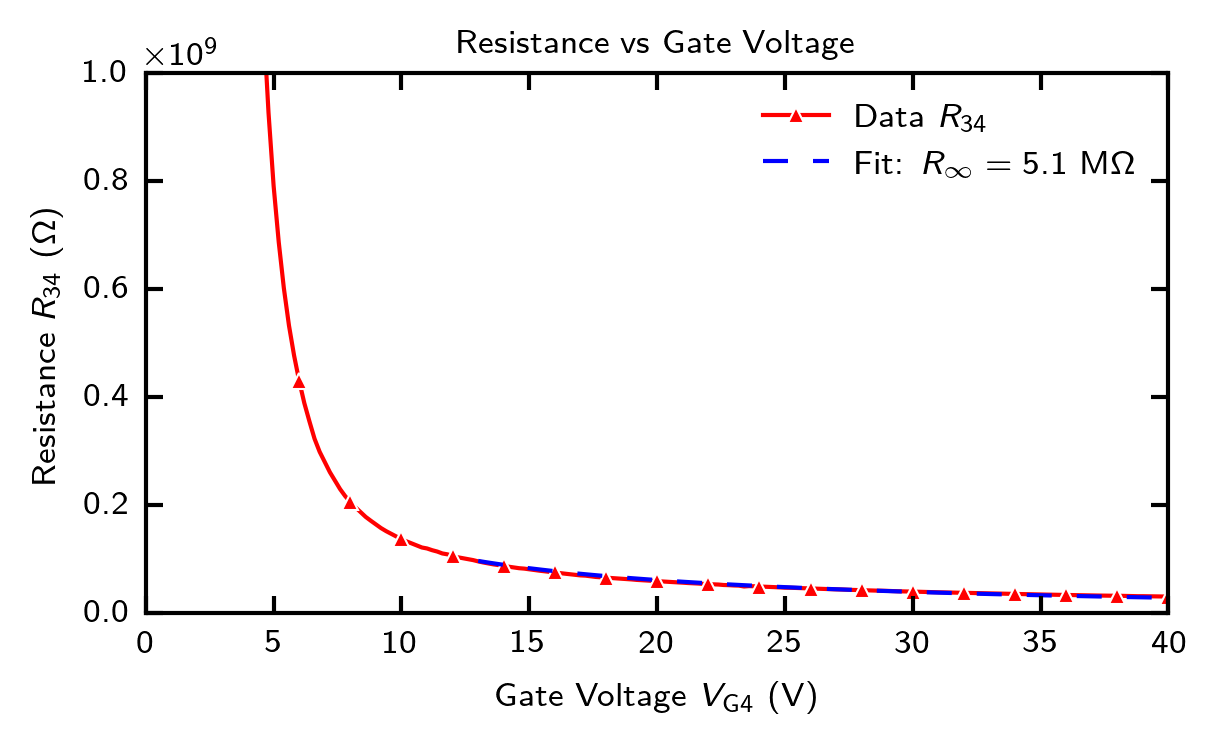

In [46]:
V_T = -5.9
def func(x, a, b):
    return a + b / x

# Use only finite points in the requested fit window: 5 <= x <= 30
mask = np.isfinite(x) & np.isfinite(R_DS) & (x >= 10) & (x <= 40)
x_fit = x[mask]
R_fit_data = R_DS[mask]

# Fit Rc + b/x to the selected x-range
popt, pcov = curve_fit(
    func,
    x_fit,
    R_fit_data,
    p0=(10, 10),
)
R_fit = func(x_fit, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_fit_data - R_fit) ** 2)
ss_tot = np.sum((R_fit_data - np.mean(R_fit_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr



print(f"a = R_\\infty = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")

x_plot = np.linspace(13, 40, 100)
R_plot = func(x_plot, *popt)
plt.plot(x, R_DS, label=r'Data $R_\text{34}$', color='red', marker='^', markevery=10)
plt.plot(x_plot, R_plot, label=rf'Fit: $R_\infty = {-a*1e-6:.2g}$ M$\Omega$', color='blue', linestyle='--')
plt.xlabel(r"Gate Voltage $V_\text{G4}$ (V)")
plt.ylabel(r"Resistance $R_\text{34}$ ($\Omega$)")
plt.xlim(0,40)
plt.ylim(0, 1e9)
plt.legend()
plt.title("Resistance vs Gate Voltage")
plt.savefig('resistance_PS9.eps', format='eps')
plt.show()